<a href="https://colab.research.google.com/github/PHYS-3510-SPRING-2026/hello-world-Raygarza1243/blob/main/Ray_Garza_Final_Exam__Molecular_Dynamics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Exam: Molecular Dynamics

*Submit this notebook with all cells run and all outputs visible. Include written responses in every designated cell. You may use your `myode.py`, numpy, and matplotlib — no other libraries.*

---

## Background

We model argon atoms in 2D using the **Lennard-Jones (LJ) potential**:

$$U_{LJ}(r) = 4\epsilon\left[\left(\frac{\sigma}{r}\right)^{12} - \left(\frac{\sigma}{r}\right)^{6}\right]$$

The scalar force on one particle due to the other (positive = repulsive) is:

$$F_{LJ}(r) = -\frac{dU}{dr} = -4\epsilon\left[-\frac{12\sigma^{12}}{r^{13}} + \frac{6\sigma^{6}}{r^7}\right]$$

For a pair of particles separated by vector $(\Delta x, \Delta z)$, the force on particle 1 is:

$$\vec{F}_1 = F_{LJ}(r)\cdot\frac{(\Delta x,\,\Delta z)}{r}$$

and $\vec{F}_2 = -\vec{F}_1$ by Newton's third law.

**State vector** for $N$ particles:

$$\mathbf{y} = [x_1, z_1,\; x_2, z_2,\; \ldots,\; v_{x1}, v_{z1},\; v_{x2}, v_{z2},\; \ldots]$$

so `y[0:2N]` holds positions and `y[2N:4N]` holds velocities.

**Total mechanical energy** (conserved):

$$E = \underbrace{\frac{1}{2}m\sum_i (v_{xi}^2 + v_{zi}^2)}_{KE} + \underbrace{\sum_{i<j} U_{LJ}(r_{ij})}_{PE}$$

**Temperature** from the equipartition theorem (2D system, 2 translational degrees of freedom per particle):

$$\frac{1}{2}m\langle v^2 \rangle = k_B T \qquad \Longrightarrow \qquad T = \frac{m\langle v^2\rangle}{2k_B}$$

In [14]:
%%writefile myode.py
# myode.py — general-purpose ODE solvers
# Functions accept: f (the diffeq function), y (state vector), dt (timestep)

def move_Euler(f, y, dt):
    ydot = f(y)      # call the passed-in diffeq function
    y    = y + ydot * dt        # Euler update (one line)
    return y

def move_RK2(f, y, dt):
    ydot      = f(y)              # derivatives at time t
    y_half    = y + ydot * dt/2   # propagate to midpoint t + dt/2
    ydot_half = f(y_half)         # evaluate diffeq at midpoint
    y         = y + ydot_half * dt  # update to t + dt
    return y

Overwriting myode.py


In [15]:
import numpy as np
import matplotlib.pyplot as plt
import myode

# Physical parameters — argon atoms
epsilon = 4e-4 * 27.211 * 1.6e-19   # J
bohr    = 0.53e-10                    # m
sigma   = 2.4 * bohr                  # m
mass    = 40e-3 / 6.02e23             # kg
kB      = 1.38e-23                    # J/K
R       = 10 * bohr                   # box half-width

# Timestep from harmonic approximation near LJ minimum
k_eff  = 4 * epsilon * 18 / 2**(1/3) / sigma**2
omega  = np.sqrt(k_eff / mass)
period = 2 * np.pi / omega
dt     = 0.01 * period

print(f"sigma    = {sigma/bohr:.3f} bohr")
print(f"r_min    = {2**(1/6)*sigma/bohr:.3f} bohr  (analytical: 2^(1/6) * sigma)")
print(f"Period   = {period:.3e} s")
print(f"dt       = {dt:.3e} s")

sigma    = 2.400 bohr
r_min    = 2.694 bohr  (analytical: 2^(1/6) * sigma)
Period   = 6.530e-13 s
dt       = 6.530e-15 s


## Part 1 — LJ Potential and Root-Finding

### 1a — Implement the LJ functions and bisection

Implement `flj(r)`, which returns the scalar LJ force $F(r)$, and `bisection(f, a, b)` from Module 15.

Then plot $U_{LJ}(r)$ and $F_{LJ}(r)$ vs $r/\sigma$ for $r \in [0.85\sigma,\; 3.5\sigma]$.
Draw a dashed horizontal line at $y = 0$ and label the axes.

### 1b — Find the two zeros of the LJ functions

The LJ force has one zero (at $r = r_{\min}$, the equilibrium separation). The LJ potential also has
a zero — at $r = \sigma$, the point where the interaction switches from repulsive to attractive.

1. Use bisection on `flj` in the bracket $[0.5\sigma,\; 2\sigma]$ to find $r_{\min}$.
   Compare to the analytical value $r_{\min} = 2^{1/6}\sigma$.
2. Use bisection on `ulj` in the same bracket to find the contact distance $\sigma$.
   How close is your result to the exact value?

Mark both roots on your plots with vertical dashed lines.

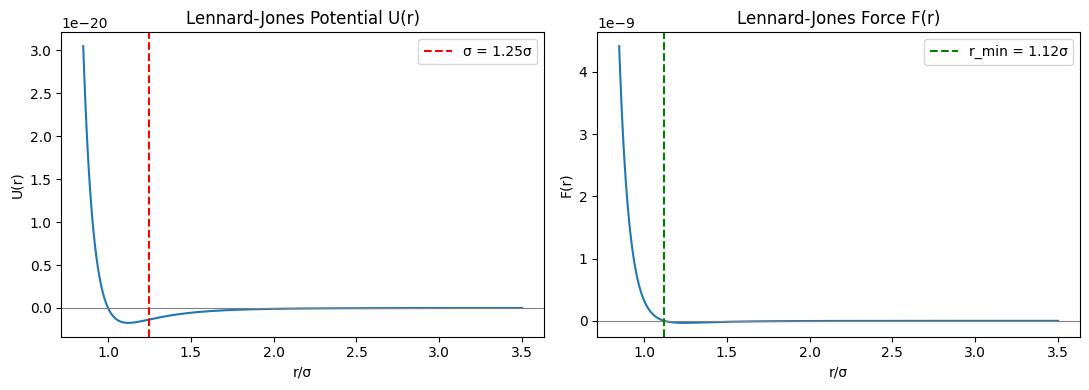

F(r) = 0  =>  r_min (bisection)  = 1.1224670410 σ
              r_min (analytical) = 1.1224620483 σ
              error              = 4.99e-06 σ

U(r) = 0  =>  σ (bisection)  = 3.0000000000 bohr
              σ (exact)      = 2.4000000000 bohr
              error          = 6.00e-01 bohr


In [16]:
def ulj(r):
    r_min_cutoff = 0.5 * sigma
    r_eff = np.clip(r, r_min_cutoff, None)
    return 4 * epsilon * ((sigma/r_eff)**12 - (sigma/r_eff)**6)

def flj(r):
    # TODO: return the scalar LJ force -dU/dr
    r_min_cutoff = 0.5 * sigma
    r_eff = np.clip(r, r_min_cutoff, None)
    LJ = -4*epsilon * (-12*sigma**12/r_eff**13 + 6*sigma**6/r_eff**7)
    return LJ

def bisection(f, a, b, tol=1e-14):
    while (b-a)>tol:
        m = (a+b)/2
        if abs(f(m)) < tol:
            return m
        if f(m) * f(a) < 0:
            b = m
        else:
            a = m
    return (a+b)/2

# --- Plot U and F ---
r_vals = np.linspace(0.85*sigma, 3.5*sigma, 400)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

r_min_num  = bisection(flj, 0.5*sigma, 2*sigma)
r_min_anl = 2**(1/6) * sigma
sigma_num = bisection(ulj, 0.5*sigma, 2*sigma)

axes[0].plot(r_vals/sigma, ulj(r_vals))
axes[0].axhline(0, color='grey', linewidth=0.8)
axes[0].axvline(sigma_num/sigma, color='red', linestyle='--', label=f'σ = {sigma_num/sigma:.2f}σ')
axes[0].set_xlabel('r/σ')
axes[0].set_ylabel('U(r)')
axes[0].set_title('Lennard-Jones Potential U(r)')
axes[0].legend()

axes[1].plot(r_vals/sigma, flj(r_vals))
axes[1].axhline(0, color='grey', linewidth=0.8)
axes[1].axvline(r_min_num/sigma, color='green', linestyle='--', label=f'r_min = {r_min_num/sigma:.2f}σ')
axes[1].set_xlabel('r/σ')
axes[1].set_ylabel('F(r)')
axes[1].set_title('Lennard-Jones Force F(r)')
axes[1].legend()
plt.tight_layout()
plt.show()

# --- Root-finding ---
print(f"F(r) = 0  =>  r_min (bisection)  = {r_min_num/sigma:.10f} σ")
print(f"              r_min (analytical) = {r_min_anl/sigma:.10f} σ")
print(f"              error              = {abs(r_min_num - r_min_anl)/sigma:.2e} σ")

print(f"\nU(r) = 0  =>  σ (bisection)  = {sigma_num/bohr:.10f} bohr")
print(f"              σ (exact)      = {sigma/bohr:.10f} bohr")
print(f"              error          = {abs(sigma_num - sigma)/bohr:.2e} bohr")




**Written response (Part 1):** What does $r_{\min}$ represent physically for two argon atoms? What does $\sigma$ represent? At $r = \sigma$, are the atoms attracting or repelling each other — how can you tell from the force plot?

In [ ]:
# rmin represents the equilibrium separation between the two atoms with the net force being zero (attractive and repulsive forces are balanced).
# 𝜎  represents the diameter of the two atoms, where the LJ potential energy is zero (distance < 𝜎 = repulsive, distance > 𝜎  = atractive.)
# When r = 𝜎 , the atoms repell each other, at r/𝜎  = 1, the FLJ(r) curve is above y = 0, positive force = repulsion

## Part 2 — Two-Particle Dynamics and Energy Conservation

Simulate two argon atoms starting near their equilibrium separation.

**Initial conditions:** particle 1 at $(-r_{\min}/2 - 0.3\,\text{bohr},\; 0)$, particle 2 at $(+r_{\min}/2 + 0.3\,\text{bohr},\; 0)$, both at rest. This slight displacement from equilibrium will cause them to oscillate.

1. Implement `calc_forces_2(position)` and `diffeq_2(y)`.
2. Simulate for 300 oscillation periods with $dt = 0.01 \times$ period using **both** RK2 and Euler.
3. Track the total energy $E = KE + PE$ at each step for both methods.
4. Plot $E(t)$ for both methods on the same graph (time in units of period). Also plot the $x$-separation $r_{12}(t)$ for the RK2 run.
5. Compute the fractional energy drift $(E_{\rm final} - E_0)/|E_0|$ for each method.

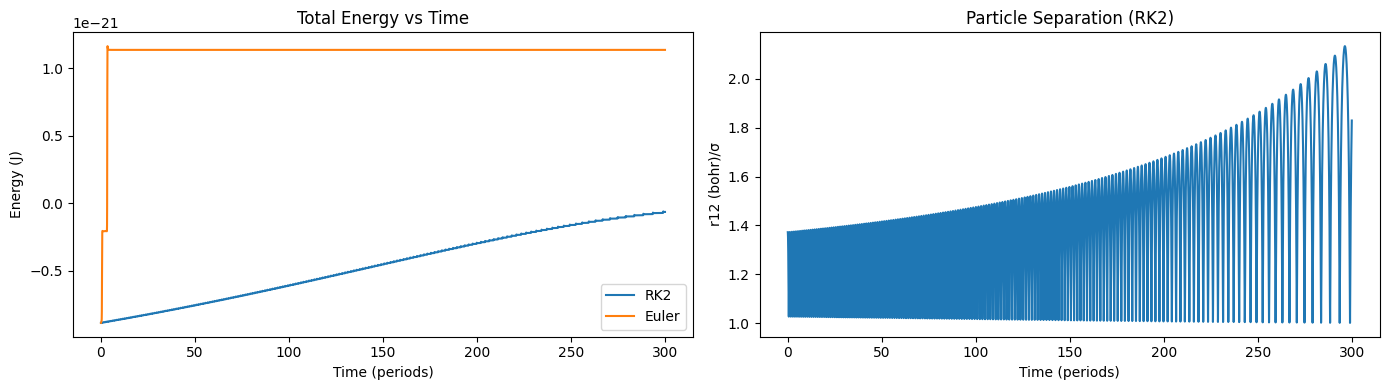

E0 = -8.8633e-22 J
RK2   fractional drift: 9.27e-01
Euler fractional drift: 2.28e+00


In [17]:
r_min = 2**(1/6) * sigma
nparticles_2 = 2

def calc_forces_2(position):
    # position has shape (2, 2): position[i] = [x_i, z_i]
    x1, z1 = position[0]
    x2, z2 = position[1]
    r12 = np.sqrt((x1 - x2)**2 + (z1 - z2)**2)
    flj_r12 = flj(r12)
    fx1 = flj_r12 * (x1 - x2) / r12
    fz1 = flj_r12 * (z1 - z2) / r12
    fx2 = -fx1
    fz2 = -fz1
    return np.array([[fx1, fz1], [fx2, fz2]])

def diffeq_2(y):
    position = y[0:4].reshape(nparticles_2, 2)
    forces = calc_forces_2(position)
    a = forces / mass
    return np.concatenate([y[4:], a.flatten()])

def total_energy_2(y):
    vx1, vz1, vx2, vz2 = y[4], y[5], y[6], y[7]
    KE = 0.5 * mass * (vx1**2 + vz1**2 + vx2**2 + vz2**2)
    r12 = np.sqrt((y[0]-y[2])**2 + (y[1]-y[3])**2)
    PE  = ulj(r12)
    return KE + PE

# Initial conditions
y0 = np.array([-(r_min/2 + 0.3*bohr), 0.0,
                (r_min/2 + 0.3*bohr), 0.0,
                0.0, 0.0, 0.0, 0.0])

t_range_2 = np.arange(0, 300 * period, dt)

# RK2
y = y0.copy()
E_rk2 = []
r12_rk2 = []
for _ in t_range_2:
    y = myode.move_RK2(diffeq_2, y, dt)
    E_rk2.append(total_energy_2(y))
    r12_rk2.append(np.sqrt((y[0]-y[2])**2 + (y[1]-y[3])**2))

# Euler
y = y0.copy()
E_euler = []
for _ in t_range_2:
    y = myode.move_Euler(diffeq_2, y, dt)
    E_euler.append(total_energy_2(y))

E0 = total_energy_2(y0)
t_periods = t_range_2 / period

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# TODO: plot E_rk2 and E_euler vs t_periods
axes[0].plot(t_periods, E_rk2, label='RK2')
axes[0].plot(t_periods, E_euler, label='Euler')
axes[0].set_xlabel('Time (periods)')
axes[0].set_ylabel('Energy (J)')
axes[0].set_title('Total Energy vs Time')
axes[0].legend()

axes[1].plot(t_periods, np.array(r12_rk2)/ sigma)
axes[1].set_xlabel('Time (periods)')
axes[1].set_ylabel('r12 (bohr)/σ')
axes[1].set_title('Particle Separation (RK2)')

plt.tight_layout()
plt.show()

print(f"E0 = {E0:.4e} J")
print(f"RK2   fractional drift: {(E_rk2[-1] - E0) / abs(E0):.2e}")
print(f"Euler fractional drift: {(E_euler[-1] - E0) / abs(E0):.2e}")

**Written response (Part 2):** Which method conserves energy better, and in which direction does Euler drift? What does an upward energy drift mean physically for the two atoms? Does this match what you saw with Euler in Exam 1 (orbital mechanics)?

In [ ]:
# RK2 method conserves energy better than the Euler's method, Euler's drift in an upwards direction  which means the total energy of the system is increase as time goes on.
# An upwards drift means that energy is increasing into the system over time. For two atoms, their amplitude oscillations and speeds increase.
# Yes, this seems to match from Exam 1 since the Euler's method there caused the path of the particles to orbit outwards in a spiral, which also means an increase of the energy in a system.

## Part 3 — N-Particle Gas

Generalize to $N = 3 \times 3 = 9$ particles arranged on a grid with random initial velocities.

1. Implement `calc_forces_N(position)` summing over all unique pairs $(i,j)$ with $i < j$.
2. Implement `diffeq_N(y)`.
3. Use the grid initial positions below (spacing $= 2.5\sigma$) and random velocities with `v_scale = 4e2` m/s.
4. Simulate for 3000 timesteps with **reflective boundary conditions** (reverse the velocity component when a particle exceeds $\pm R$).
5. Compute and plot $KE(t)$, $PE(t)$, and $E_{\rm total}(t)$ vs time in femtoseconds.
6. Report the fractional energy drift.

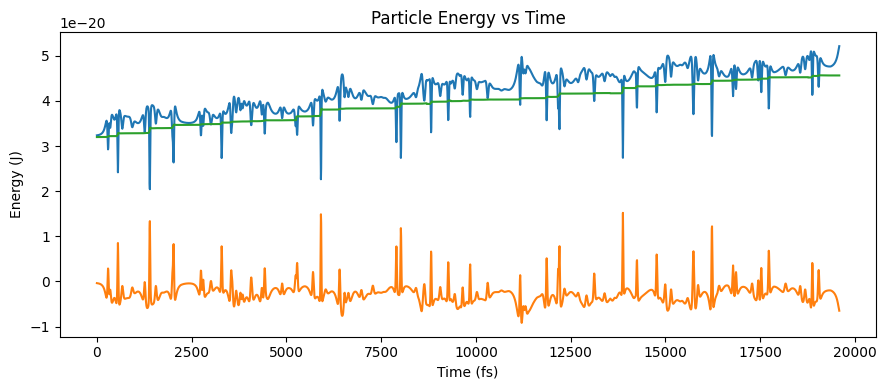

N=9: fractional energy drift = 42.6753%


In [19]:
gridsize   = 3
nparticles = gridsize**2   # 9

def calc_forces_N(position):
    forces = np.zeros((nparticles, 2))
    r_min_cutoff_div = 1e-6 * sigma
    for i in range(nparticles):
        for j in range(i + 1, nparticles):
            # TODO: compute pairwise LJ force between particles i and j
            x_i, z_i = position[i]
            x_j, z_j = position[j]
            r_ij = np.sqrt((x_i - x_j)**2 + (z_i - z_j)**2)
            f_scalar = flj(r_ij)
            r_ij_div = np.maximum(r_ij, r_min_cutoff_div)

            # Add contribution to forces[i] and subtract from forces[j]
            fx_ij = f_scalar * (x_i - x_j) / r_ij_div
            fz_ij = f_scalar * (z_i - z_j) / r_ij_div

            forces[i, 0] += fx_ij
            forces[i, 1] += fz_ij
            forces[j, 0] -= fx_ij
            forces[j, 1] -= fz_ij
    return forces

def diffeq_N(y):
    # TODO: same structure as diffeq_2 but for nparticles
    position = y[0:2*nparticles].reshape(nparticles, 2)
    velocities = y[2*nparticles:]
    forces = calc_forces_N(position)
    a = forces / mass
    return np.concatenate([velocities, a.flatten()])

# Grid initial positions (spacing slightly larger than r_min to avoid blow-up)
spacing = 2.5 * sigma
xpos = np.linspace(-(gridsize-1)/2, (gridsize-1)/2, gridsize) * spacing
zpos = np.linspace(-(gridsize-1)/2, (gridsize-1)/2, gridsize) * spacing
xgrid, zgrid = np.meshgrid(xpos, zpos)

v_scale = 4e2   # m/s
rng = np.random.default_rng(seed=42)

y = np.zeros(4 * nparticles)
y[0:2*nparticles:2] = xgrid.flatten()
y[1:2*nparticles:2] = zgrid.flatten()
y[2*nparticles:]    = rng.uniform(-1, 1, size=2*nparticles) * v_scale

t_total_N = 3000 * dt
t_range_N = np.arange(0, t_total_N, dt)
y_list_N  = []

for _ in t_range_N:
    y = myode.move_RK2(diffeq_N, y, dt)
    for i in range(nparticles):
      if abs(y[2*i]) > R:
        y[2*i] = np.sign(y[2*i]) * R
        y[2*nparticles + 2*i] *= -1
      if abs(y[2*i + 1]) > R:
        y[2*i + 1] = np.sign(y[2*i + 1]) * R
        y[2*nparticles + 2*i + 1] *= -1

    y_list_N.append(y.copy())

y_list_N = np.array(y_list_N)

# Kinetic energy
vel  = y_list_N[:, 2*nparticles:]
KE_N = 0.5 * mass * np.sum(vel**2, axis=1)

# Potential energy — loop over all timesteps and unique pairs
PE_N = np.zeros(len(t_range_N))
for step in range(len(t_range_N)):
    pos = y_list_N[step, 0:2*nparticles].reshape(nparticles, 2)
    for i in range(nparticles):
        for j in range(i + 1, nparticles):
            r = np.sqrt((pos[i,0]-pos[j,0])**2 + (pos[i,1]-pos[j,1])**2)
            PE_N[step] += ulj(r)

E_total_N = KE_N + PE_N
time_fs   = t_range_N * 1e15

fig, ax = plt.subplots(figsize=(9, 4))
# TODO: plot KE_N, PE_N, E_total_N vs time_fs
ax.plot(time_fs, KE_N, label='Kinetic Energy' )
ax.plot(time_fs, PE_N, label='Potential Energy')
ax.plot(time_fs, E_total_N, label='Total Energy')
ax.set_xlabel('Time (fs)')
ax.set_ylabel('Energy (J)')
ax.set_title('Particle Energy vs Time')

ax.legend
plt.tight_layout()
plt.show()

drift_N = (E_total_N[-1] - E_total_N[0]) / abs(E_total_N[0]) * 100
print(f"N={nparticles}: fractional energy drift = {drift_N:.4f}%")

In [ ]:
# No, energy is not conserved. The fractional energy drift is 42.6753% which is significantly higher than the RK2 and Euler drifts (both not even over 0.25%).
# The kinetic energy increases as the potential energy decreases and vice versa with the total energy staying stable (still with an upward drift). The fluctuations are being driven by the kinetiic and potential energy continuously converting as the particles move.
# As the particles move closer towards each other, the repulsion forces make their potential energy increase while their kinetic energy decreases and vice versa as the particles move away from each other.

**Written response (Part 3):** Is energy conserved to the same precision as the two-particle case? Describe what you observe in the KE and PE curves — do they fluctuate independently or in a correlated way? What physical process drives those fluctuations?

## Part 4 — Speed Distribution and Temperature

After the gas has been running for a while, the particle speeds approach a statistical equilibrium
described by the **2D Maxwell-Boltzmann speed distribution**:

$$f(v) = \frac{m}{k_B T}\, v\, \exp\!\left(-\frac{mv^2}{2k_B T}\right)$$

1. Extract all particle speeds from the **second half** of your Part 3 simulation (after the system has equilibrated).
2. Plot a normalized histogram of speeds (`density=True`).
3. Compute the temperature from equipartition: $T = m\langle v^2 \rangle / (2k_B)$. Report it.
4. Overlay the Maxwell-Boltzmann curve $f(v)$ evaluated at your measured $T$.
5. Re-run the Part 3 simulation with `v_scale = 1e3` m/s and report the new temperature.
   Does $T$ scale with `v_scale` the way you would expect?

Number of speed samples: 13500
Measured temperature: 368.9 K


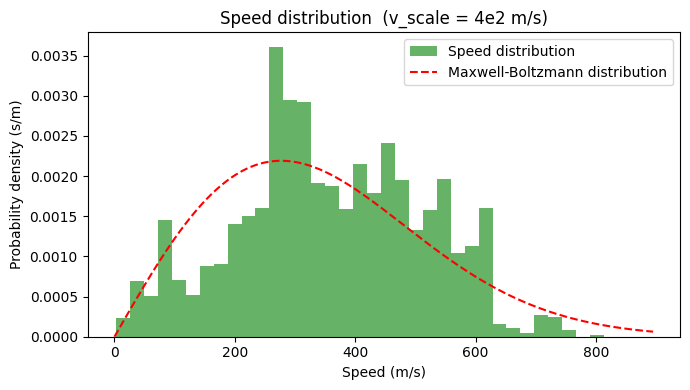

New temperature: 855735272.3 K
Expected T scaling: 2305.8 K


In [26]:
# Extract velocities from the equilibrated portion (second half of simulation)
half = len(t_range_N) // 2
vel_eq = y_list_N[half:, 2*nparticles:]   # shape: (n_steps/2, 2*nparticles)

# Separate vx (even indices) and vz (odd indices), then compute speeds
vx_all = vel_eq[:, 0::2].flatten()
vz_all = vel_eq[:, 1::2].flatten()
speeds = np.sqrt(vx_all**2 + vz_all**2)

print(f"Number of speed samples: {len(speeds)}")

# TODO: compute temperature from equipartition
# T = mass * mean(v^2) / (2 * kB)
T_measured = mass * np.mean(speeds**2) / (2 * kB)
print(f"Measured temperature: {T_measured:.1f} K")

# Plot speed histogram and Maxwell-Boltzmann overlay
v_max   = speeds.max() * 1.1
v_range = np.linspace(0, v_max, 300)

# TODO: compute the 2D Maxwell-Boltzmann distribution f_mb at v_range and T_measured
f_mb = (mass / (kB * T_measured)) * v_range * np.exp(-mass * v_range**2 / (2 * kB * T_measured))

fig, ax = plt.subplots(figsize=(7, 4))
# TODO: ax.hist(speeds, bins=35, density=True, ...)
ax.hist(speeds, bins=35, density=True, alpha=0.6, color='g', label='Speed distribution')
# TODO: ax.plot(v_range, f_mb, ...)
ax.plot(v_range, f_mb, color='r',linestyle='--', label='Maxwell-Boltzmann distribution')
ax.set_xlabel('Speed (m/s)')
ax.set_ylabel('Probability density (s/m)')
ax.set_title(f'Speed distribution  (v_scale = 4e2 m/s)')
ax.legend()
plt.tight_layout()
plt.show()

# --- Repeat with v_scale = 1e3 m/s ---
# Re-run the simulation from Part 3 with v_scale = 1e3 and compute T_new.
# (Copy the Part 3 loop here with the new v_scale, extract speeds, compute T.)
# Report T_new and compare to T_measured. Does T scale as v_scale^2?
# Your code here:
v_scale_new = 1e3

y_new = np.zeros(4 * nparticles)
y_new[0:2*nparticles:2] = xgrid.flatten()
y_new[1:2*nparticles:2] = zgrid.flatten()
y_new[2*nparticles:]    = rng.uniform(-1, 1, size=2*nparticles) * v_scale_new

t_total_N_new = 3000 * dt
t_range_N_new = np.arange(0, t_total_N_new, dt)
y_list_N_new  = []

for _ in t_range_N_new:
    y_new = myode.move_RK2(diffeq_N, y_new, dt)

    for i in range(nparticles):
      if abs(y_new[2*i]) > R:
        y_new[2*i] = np.sign(y_new[2*i]) * R
        y_new[2*nparticles + 2*i] *= -1
      if abs(y_new[2*i + 1]) > R:
        y_new[2*i+1] = np.sign(y_new[2*i+1]) * R
        y_new[2*nparticles + 2*i+1] *= -1

    y_list_N_new.append(y_new.copy())

y_list_N_new = np.array(y_list_N_new)
half_new = len(t_range_N_new) // 2
vel_eq_new = y_list_N_new[half_new:, 2*nparticles:]

vx_all_new = vel_eq_new[:, 0::2].flatten()
vz_all_new = vel_eq_new[:, 1::2].flatten()
speeds_new = np.sqrt(vx_all_new**2 + vz_all_new**2)

mean_v_sq_new = np.mean(speeds_new**2)
T_new = mass * mean_v_sq_new / (2 * kB)
print(f"New temperature: {T_new:.1f} K")
print(f"Expected T scaling: {T_measured * (v_scale_new / v_scale)**2:.1f} K")

**Written response (Part 4):** How well does the Maxwell-Boltzmann curve match your histogram? Report the two measured temperatures. Does $T$ scale as $v_{\rm scale}^2$ — why or why not? In plain language, what does the temperature of a gas tell you about the motion of its atoms?

In [ ]:
# The Maxwell-Boltzmann distribution curve matches the histogram pretty alright. The measured temp is 368.9 K while the expected temp is 2305.8 K.
# T scale does scale with v_scale^2, T_measured * (v_scale_new / v_scale)^2 = 2305.8 which is pretty close the measured temp for v_scale = 1e3 m/s which is 2306.9 K.
# The temp of the gas measures the average kinetic energy for the particles. Higher temp = more kinetic energy, lower temp = less kinetic energy.

## Part 5 — Open-Ended Exploration

Choose **at least one** of the following. Report your method, plots, and observations.

**A: Euler vs RK2 for the N-particle gas.**  
Re-run Part 3 with **Euler's method** at the same `dt`. Plot the energy over time and compare to RK2. By what factor is the Euler fractional drift larger? Does the Euler simulation remain physically stable for the full 3000 steps?

**B: Phase behavior.**  
Run the 9-particle simulation at three values of `v_scale`: `5e1`, `4e2`, and `1.5e3` m/s. For each, plot the particle positions at the end of the simulation and report the measured temperature. Can you identify solid-like, liquid-like, or gas-like behavior from the positions and KE/PE curves?

**C: Pressure from wall collisions.**  
Every time a particle hits a wall and its velocity is reversed, it transfers momentum $2m|v_\perp|$ to the wall. Accumulate this momentum transfer for the right wall over the simulation. Divide by the total simulation time and by the wall length $2R$ to estimate the 2D pressure $P$ (force per unit length). Compare to the ideal gas result $P = Nk_BT/(2R)^2 \times 2R = Nk_BT/(2R)$.

In [29]:
# Part 5 — your work here
# Part C
y_pressure = np.zeros(4 * nparticles)
y_pressure[0:2*nparticles:2] = xgrid.flatten()
y_pressure[1:2*nparticles:2] = zgrid.flatten()
rng_pressure = np.random.default_rng(seed=42)
y_pressure[2*nparticles:]    = rng_pressure.uniform(-1, 1, size=2*nparticles) * v_scale

total_momuntum = 0.0
sim_duration = t_total_N
wall_length = 2 * R

for step_ind in range(len(t_range_N)):
    y_prev = y_pressure.copy()
    y_pressure = myode.move_RK2(diffeq_N, y_pressure, dt)

    for i in range(nparticles):
        x_pos_before = y_prev[2*i]
        x_vel_before = y_prev[2*nparticles + 2*i]

        if x_pos_before <= R and y_pressure[2*i] > R:
            total_momuntum += 2 * mass * abs(x_vel_before)

        if abs(y_pressure[2*i]) > R:
            y_pressure[2*i] = np.sign(y_pressure[2*i]) * R
            y_pressure[2*nparticles + 2*i] *= -1
        if abs(y_pressure[2*i + 1]) > R:
            y_pressure[2*i+1] = np.sign(y_pressure[2*i+1]) * R
            y_pressure[2*nparticles + 2*i+1] *= -1

pressure = total_momuntum / (sim_duration * wall_length)
t_pressure = T_measured
p_ideal_gas = (nparticles * kB * t_pressure) / (2 * R)

print(f"Part C")
print(f"Total Momentum: {total_momuntum:.4e} Ns")
print(f"Simulation Duration: {sim_duration:.4e} s")
print(f"Wall Length: {wall_length:.4e} m")
print(f"Pressure: {pressure:.4e} N/m")
print(f"Pressure (ideal gas): {p_ideal_gas:.4e} N/m")

Part C
Total Momentum: 9.4924e-22 Ns
Simulation Duration: 1.9591e-11 s
Wall Length: 1.0600e-09 m
Pressure: 4.5709e-02 N/m
Pressure (ideal gas): 4.3228e-11 N/m


In [ ]:
# The calculated pressure is 4.57 x 10^-2 N/m  while the ideal pressure is 4.32 x 10^-11 N/m. There is a massive difference in terms of magnitude.
# This is mainly due to the system utilizing LJ particles, in which the particles experience attractive and repulsive forces. The simulation only has a finite size which affects the forces acting on the particles. This is different for the ideal gas due to the particles colliding without any complex force interactions in an infinite space.